# EDA

In [1]:
import pandas as pd

sentiment_df = pd.read_csv("../../../data/sentiment140/versions/2/training.1600000.processed.noemoticon.csv",
                 encoding="latin-1",
                header=None,
                names=["target", "id", "date", "flag", "user", "text"])
sentiment_df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [2]:
sentiment_df.shape

(1600000, 6)

In [3]:
sentiment_df.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [4]:
# 0 : negative, 4 : positive
sentiment_df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

# positive/negative word cloud 그리기

## positive/negative df 분리

In [5]:
pos_df = sentiment_df[sentiment_df['target'] == 4]
neg_df = sentiment_df[sentiment_df['target'] == 0]
print("Positive sentiment")
print(pos_df.head(3))
print("Negative sentiment")
print(neg_df.head(3))

Positive sentiment
        target          id                          date      flag       user  \
800000       4  1467822272  Mon Apr 06 22:22:45 PDT 2009  NO_QUERY      ersle   
800001       4  1467822273  Mon Apr 06 22:22:45 PDT 2009  NO_QUERY   becca210   
800002       4  1467822283  Mon Apr 06 22:22:46 PDT 2009  NO_QUERY  Wingman29   

                                                     text  
800000       I LOVE @Health4UandPets u guys r the best!!   
800001  im meeting up with one of my besties tonight! ...  
800002  @DaRealSunisaKim Thanks for the Twitter add, S...  
Negative sentiment
   target          id                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww,

## pos에 대해 각각의 word_count 구하기

In [6]:
# STOPWORDS를 필터링 하기 위해서 str.lower() 추가.
def get_word_count(df):
    return df['text'].str.lower().str.split().explode().value_counts()

pos_word_count = get_word_count(pos_df)

In [7]:
print(pos_word_count.head())
print(f"pos word count shape : {pos_word_count.shape}")

text
i      286681
the    263078
to     250026
a      196244
you    154930
Name: count, dtype: int64
pos word count shape : (766214,)


### pos word_count 에 대해 각각 크기 200이하로 샘플링
- 출현 빈도가 높으면 그 감정을 표현하고 있을 확률이 높다.
- the, a 와 같은 단어는 제외한다. => 불용어 제외

In [8]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

pos_word_count_filtered = pos_word_count[~pos_word_count.index.isin(stopwords)]
print(pos_word_count_filtered.head(3))

text
good    53593
love    44579
-       42160
Name: count, dtype: int64


## pos로 검증 후 neg에 대해서도 동일한 과정 수행

In [9]:
neg_word_count = get_word_count(neg_df)
neg_word_count_filtered = neg_word_count[~neg_word_count.index.isin(stopwords)]

## 하나의 Plot안에 2개의 word cloud 그리기

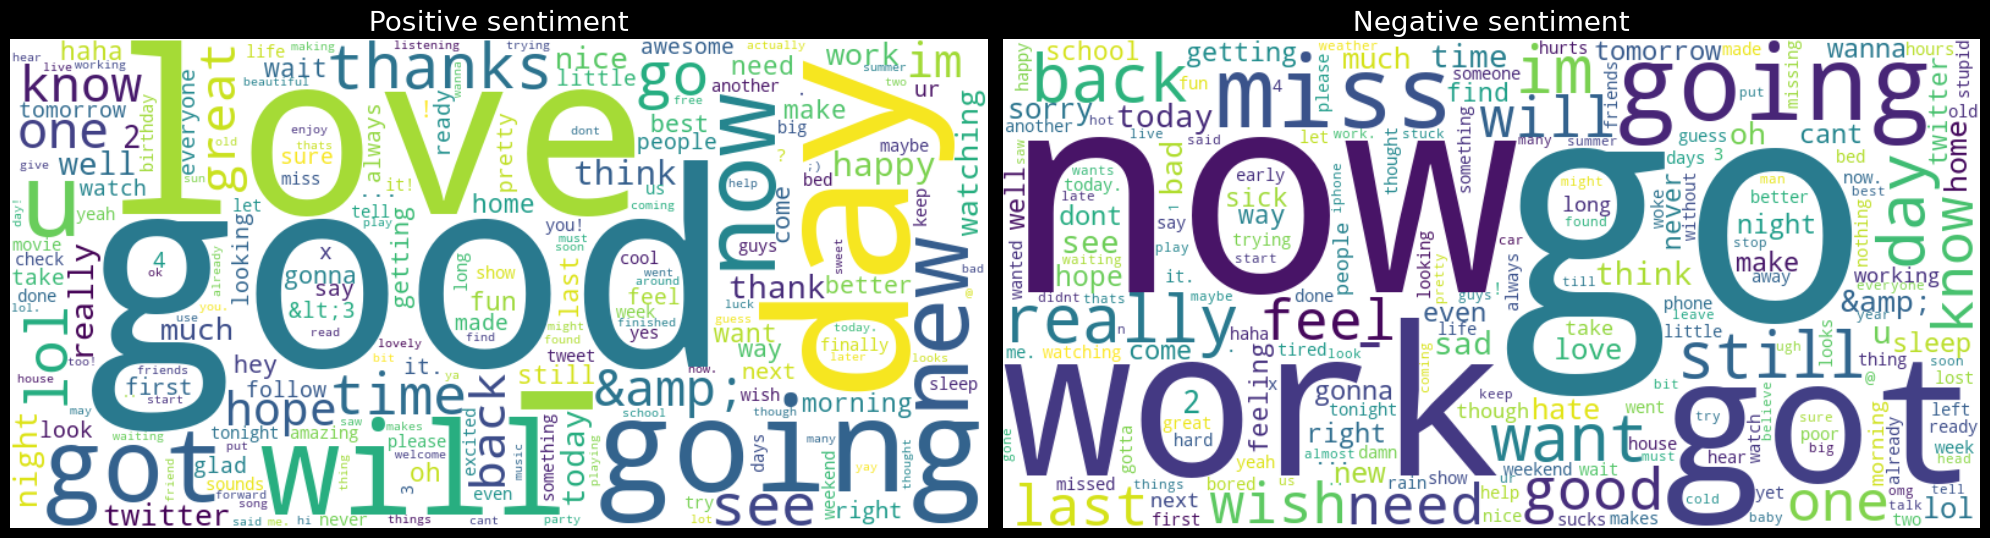

In [10]:
import matplotlib.pyplot as plt
pos_wc = WordCloud(
    width=800, height=400,
    max_words=200,
    background_color="white",
).generate_from_frequencies(pos_word_count_filtered.to_dict())

neg_wc = WordCloud(
    width=800, height=400,
    max_words=200,
    background_color="white",
).generate_from_frequencies(neg_word_count_filtered.to_dict())

fig, axes = plt.subplots(1,2, figsize=(20,10))

axes[0].imshow(pos_wc, interpolation="bilinear")
axes[0].set_title("Positive sentiment", fontsize=20)
axes[0].axis("off")

axes[1].imshow(neg_wc, interpolation="bilinear")
axes[1].set_title("Negative sentiment", fontsize=20)
axes[1].axis("off")

plt.tight_layout()
plt.show()